In [2]:
import os
import pdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys
sys.path.append(os.getcwd())
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
sns.set_theme(font_scale=2.1, style='whitegrid')
sns.color_palette("colorblind")
font = {'family' : 'serif',
            # 'weight' : 'bold',
            'size'   : 19}
mpl.rcParams['figure.dpi'] = 600
mpl.rc('font', **font)
mpl.rc('xtick', labelsize=19) 
plt.rcParams["font.family"] = "Nimbus Roman"
mpl.rc('ytick', labelsize=19)

In [4]:
# Load the results
perf_olmo = pd.read_csv(os.path.join(os.environ["base_dir"], "results", "olmo2-7B_full_v2_mult_perf.csv"))
perf_mistral = pd.read_csv(os.path.join(os.environ["base_dir"], "results", "mistral7B_full_v2_mult_perf.csv"))
perf_qwen = pd.read_csv(os.path.join(os.environ["base_dir"], "results", "qwen7B-instruct_full_v2_mult_perf.csv"))

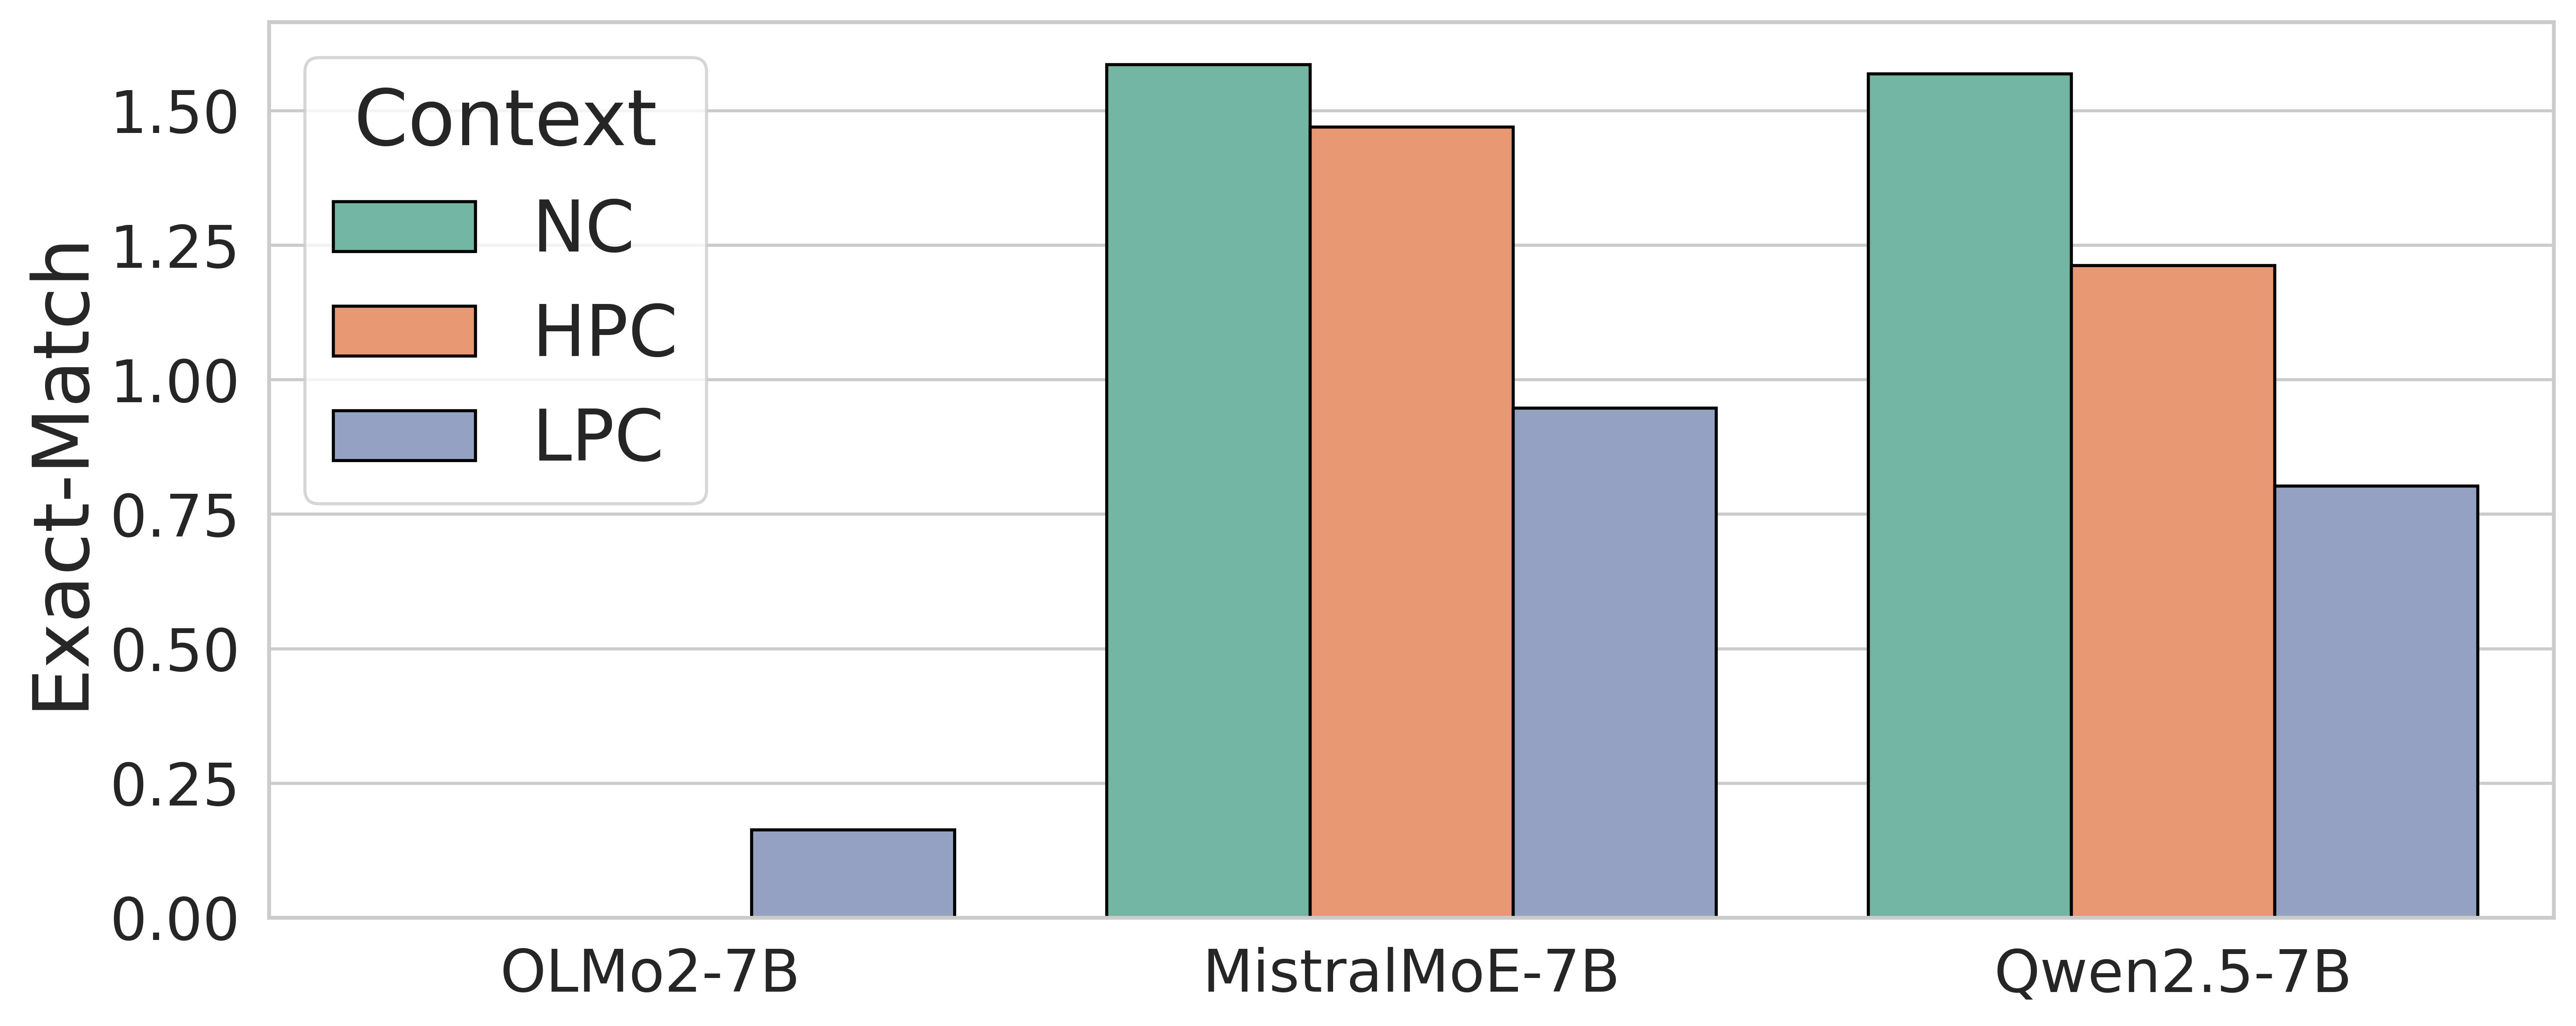

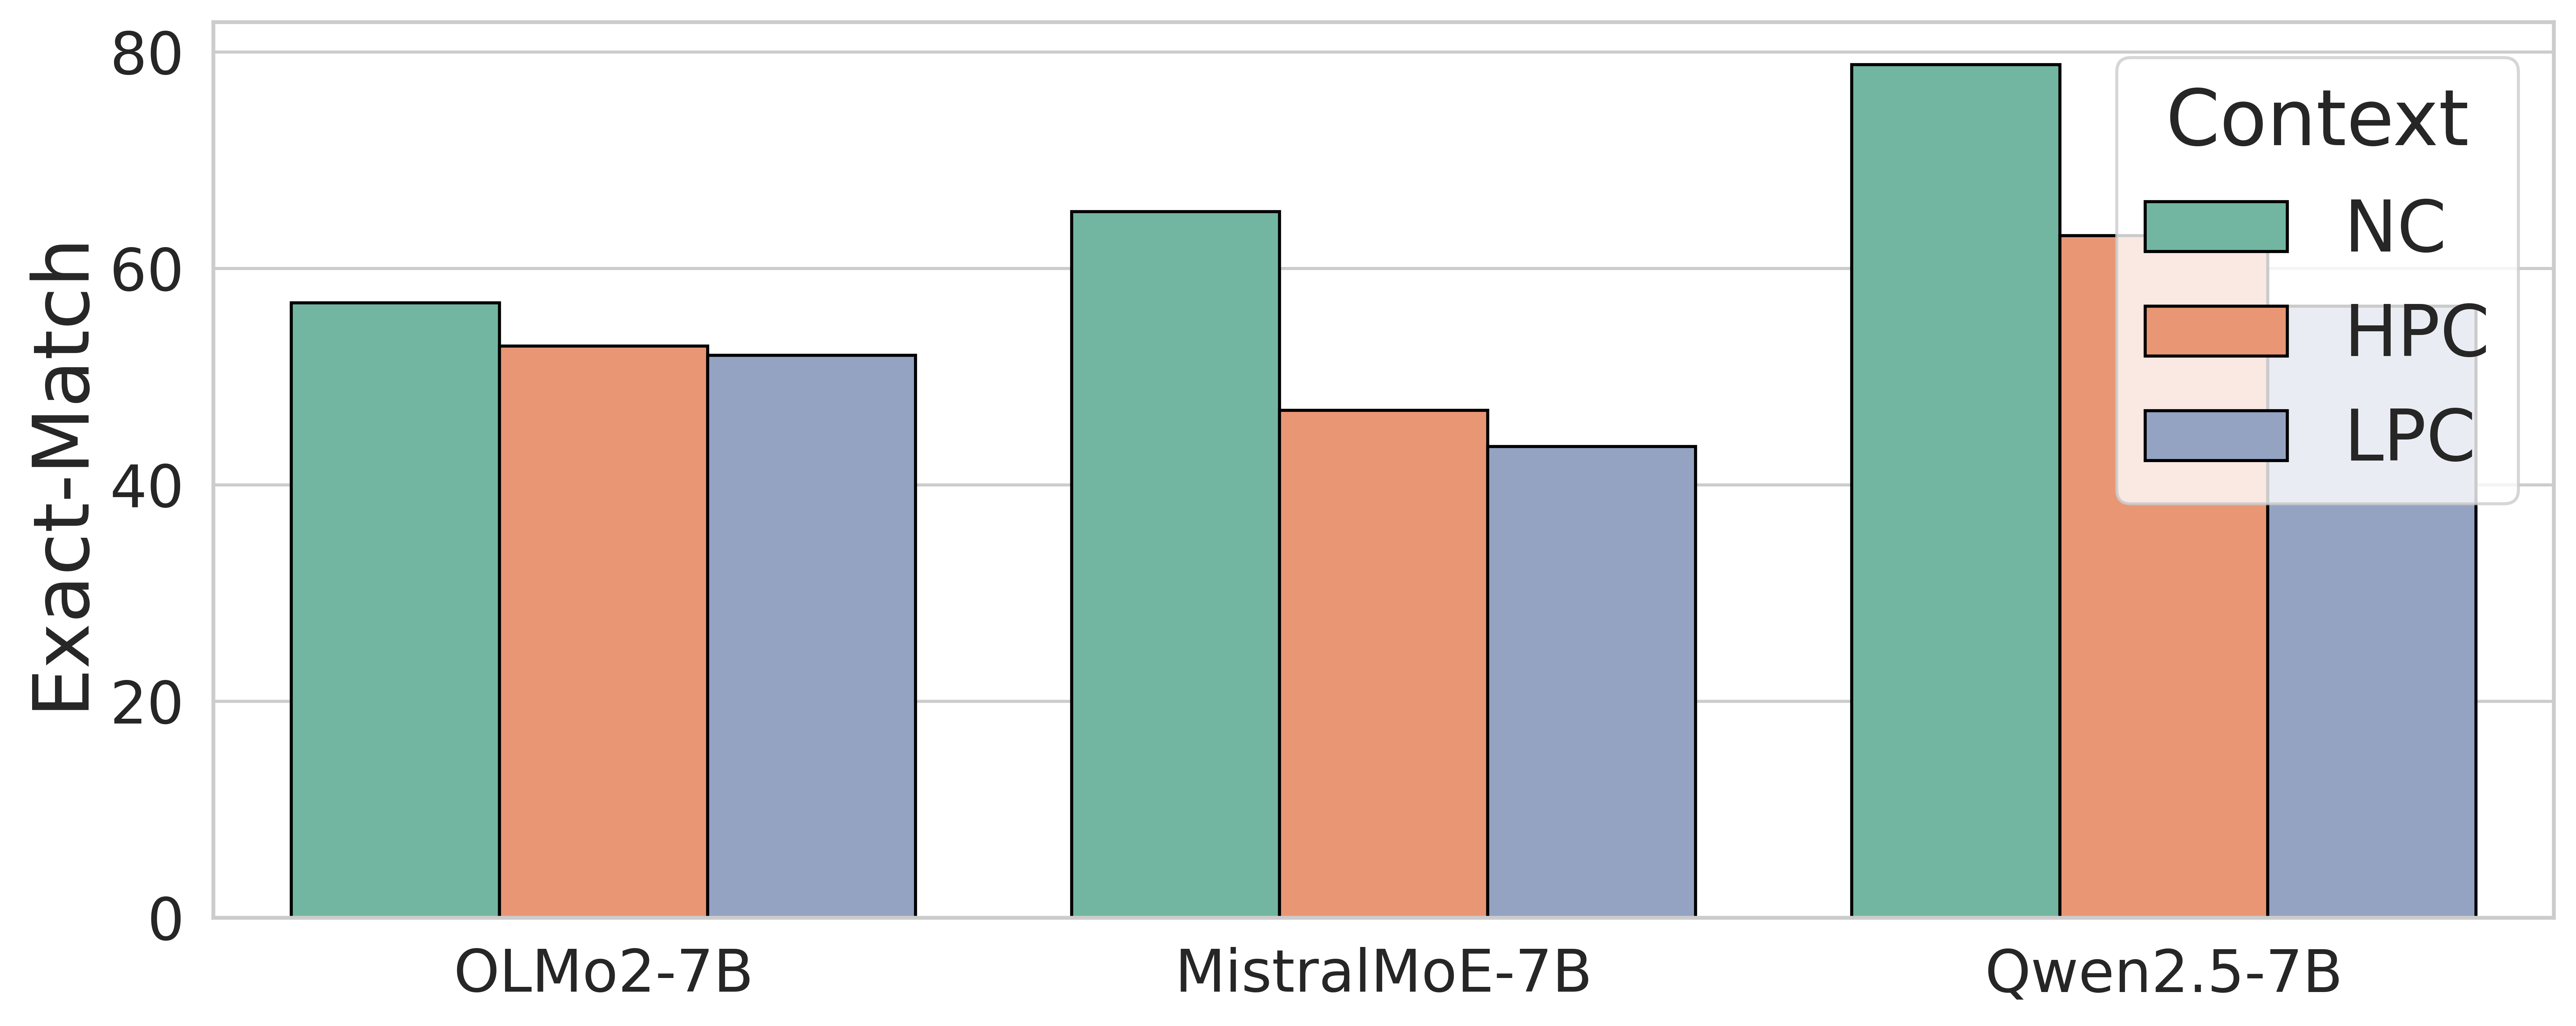

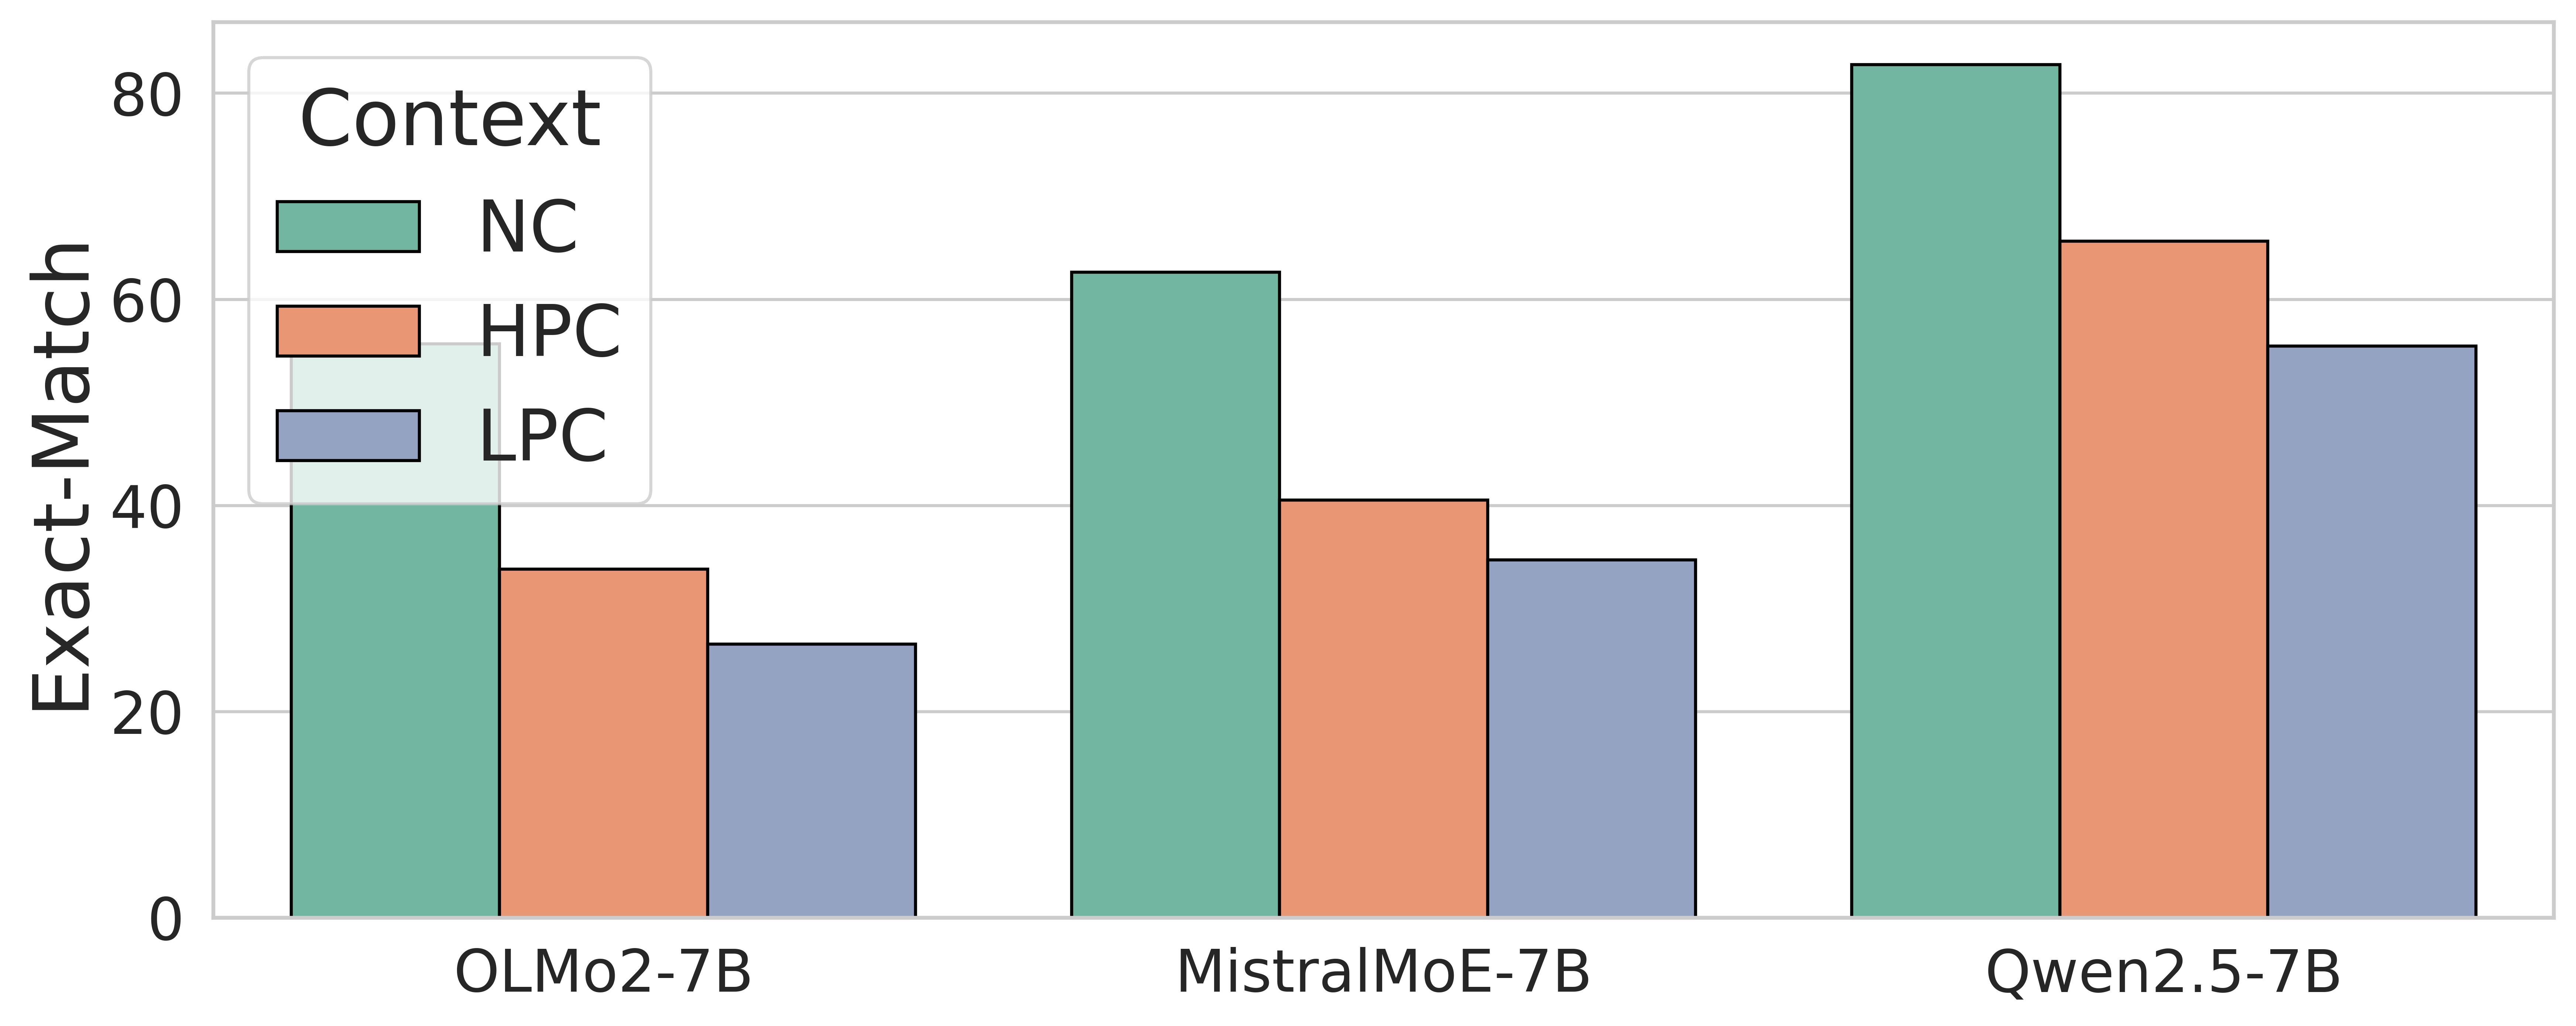

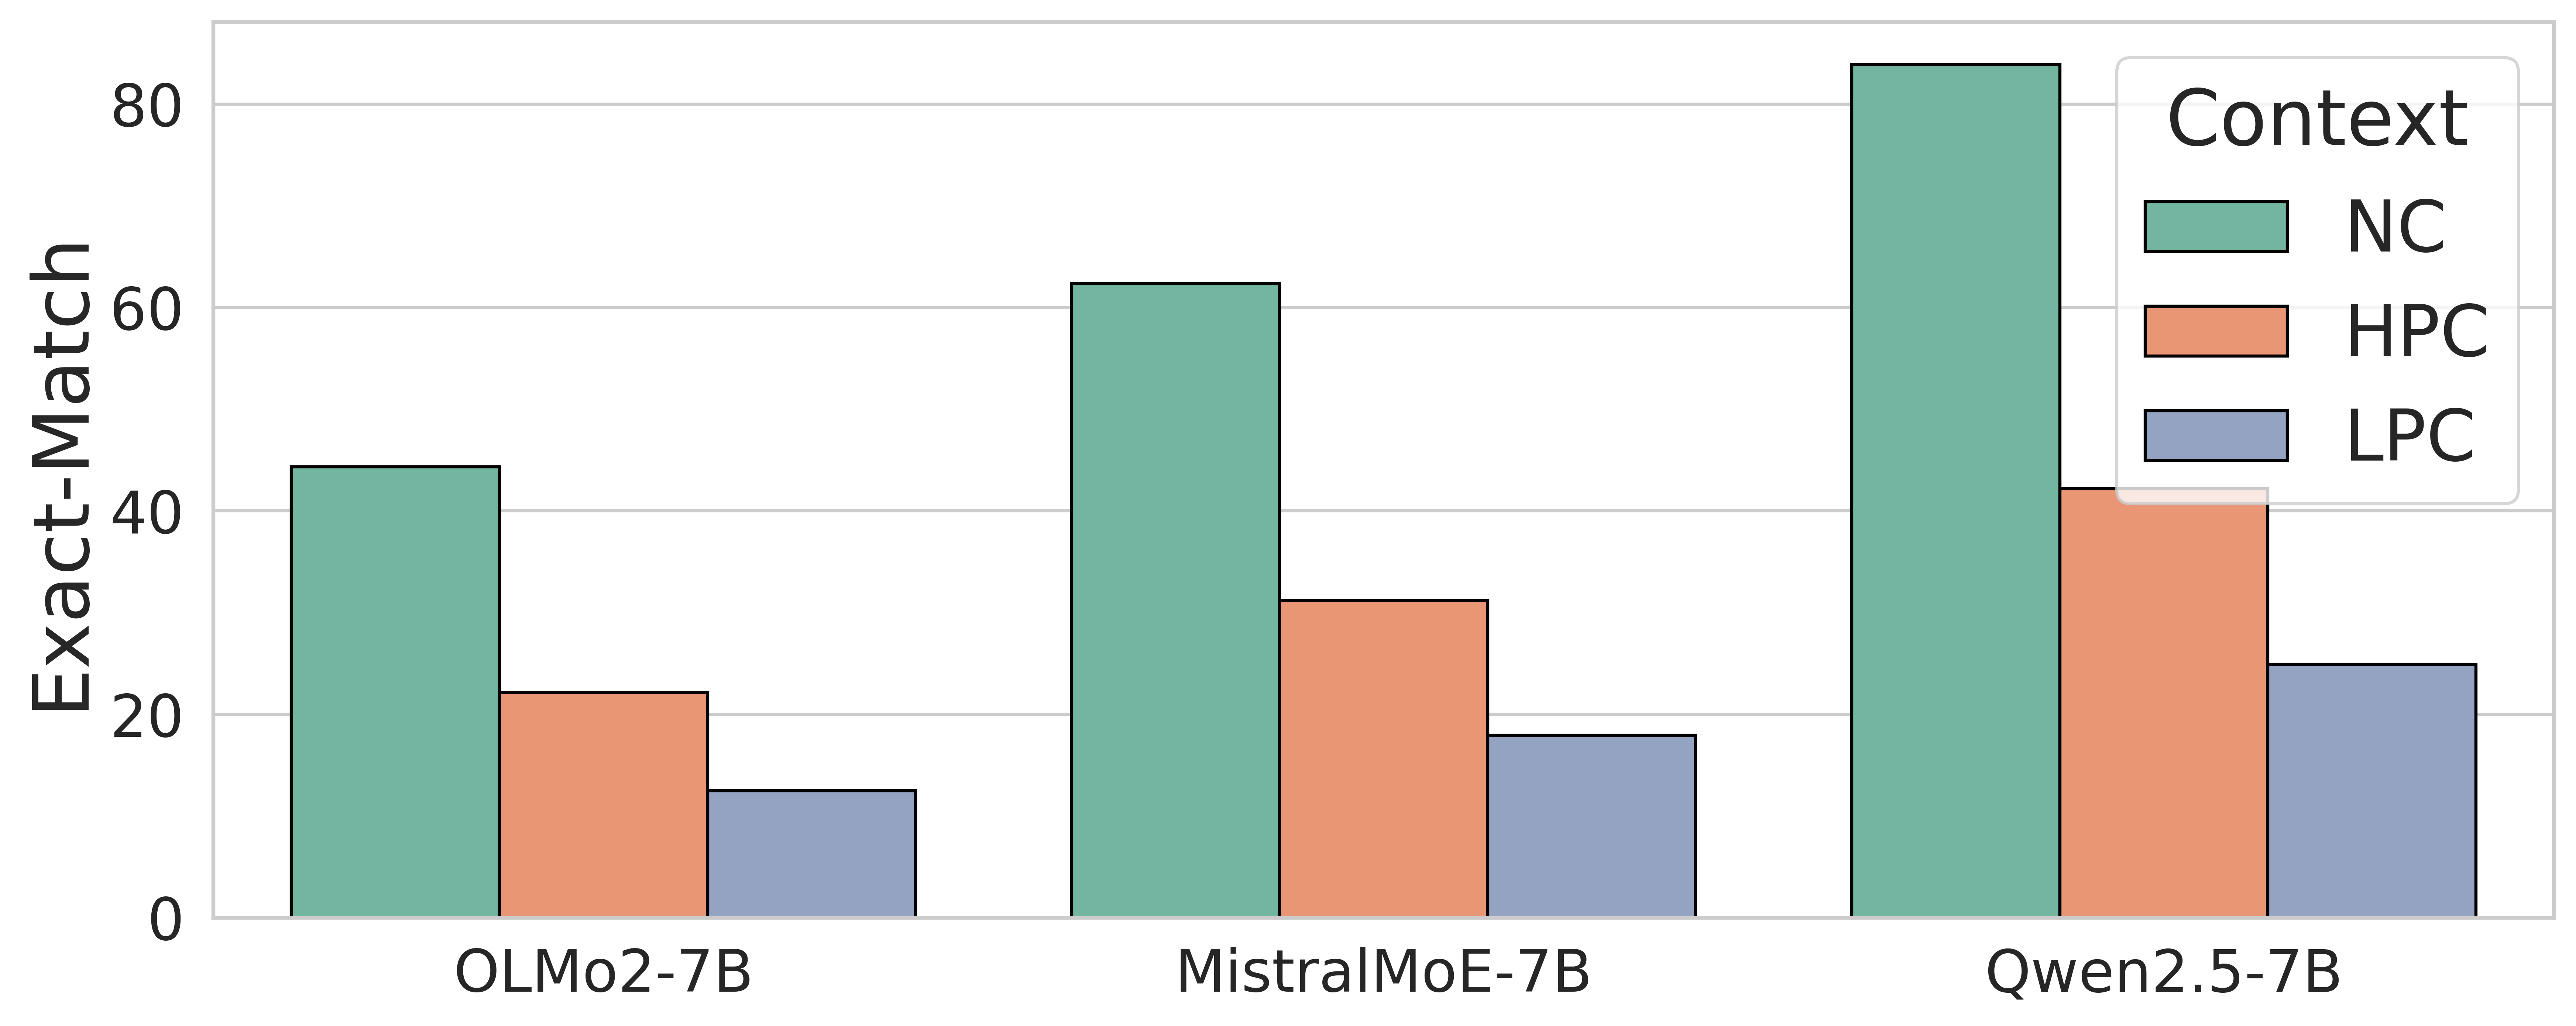

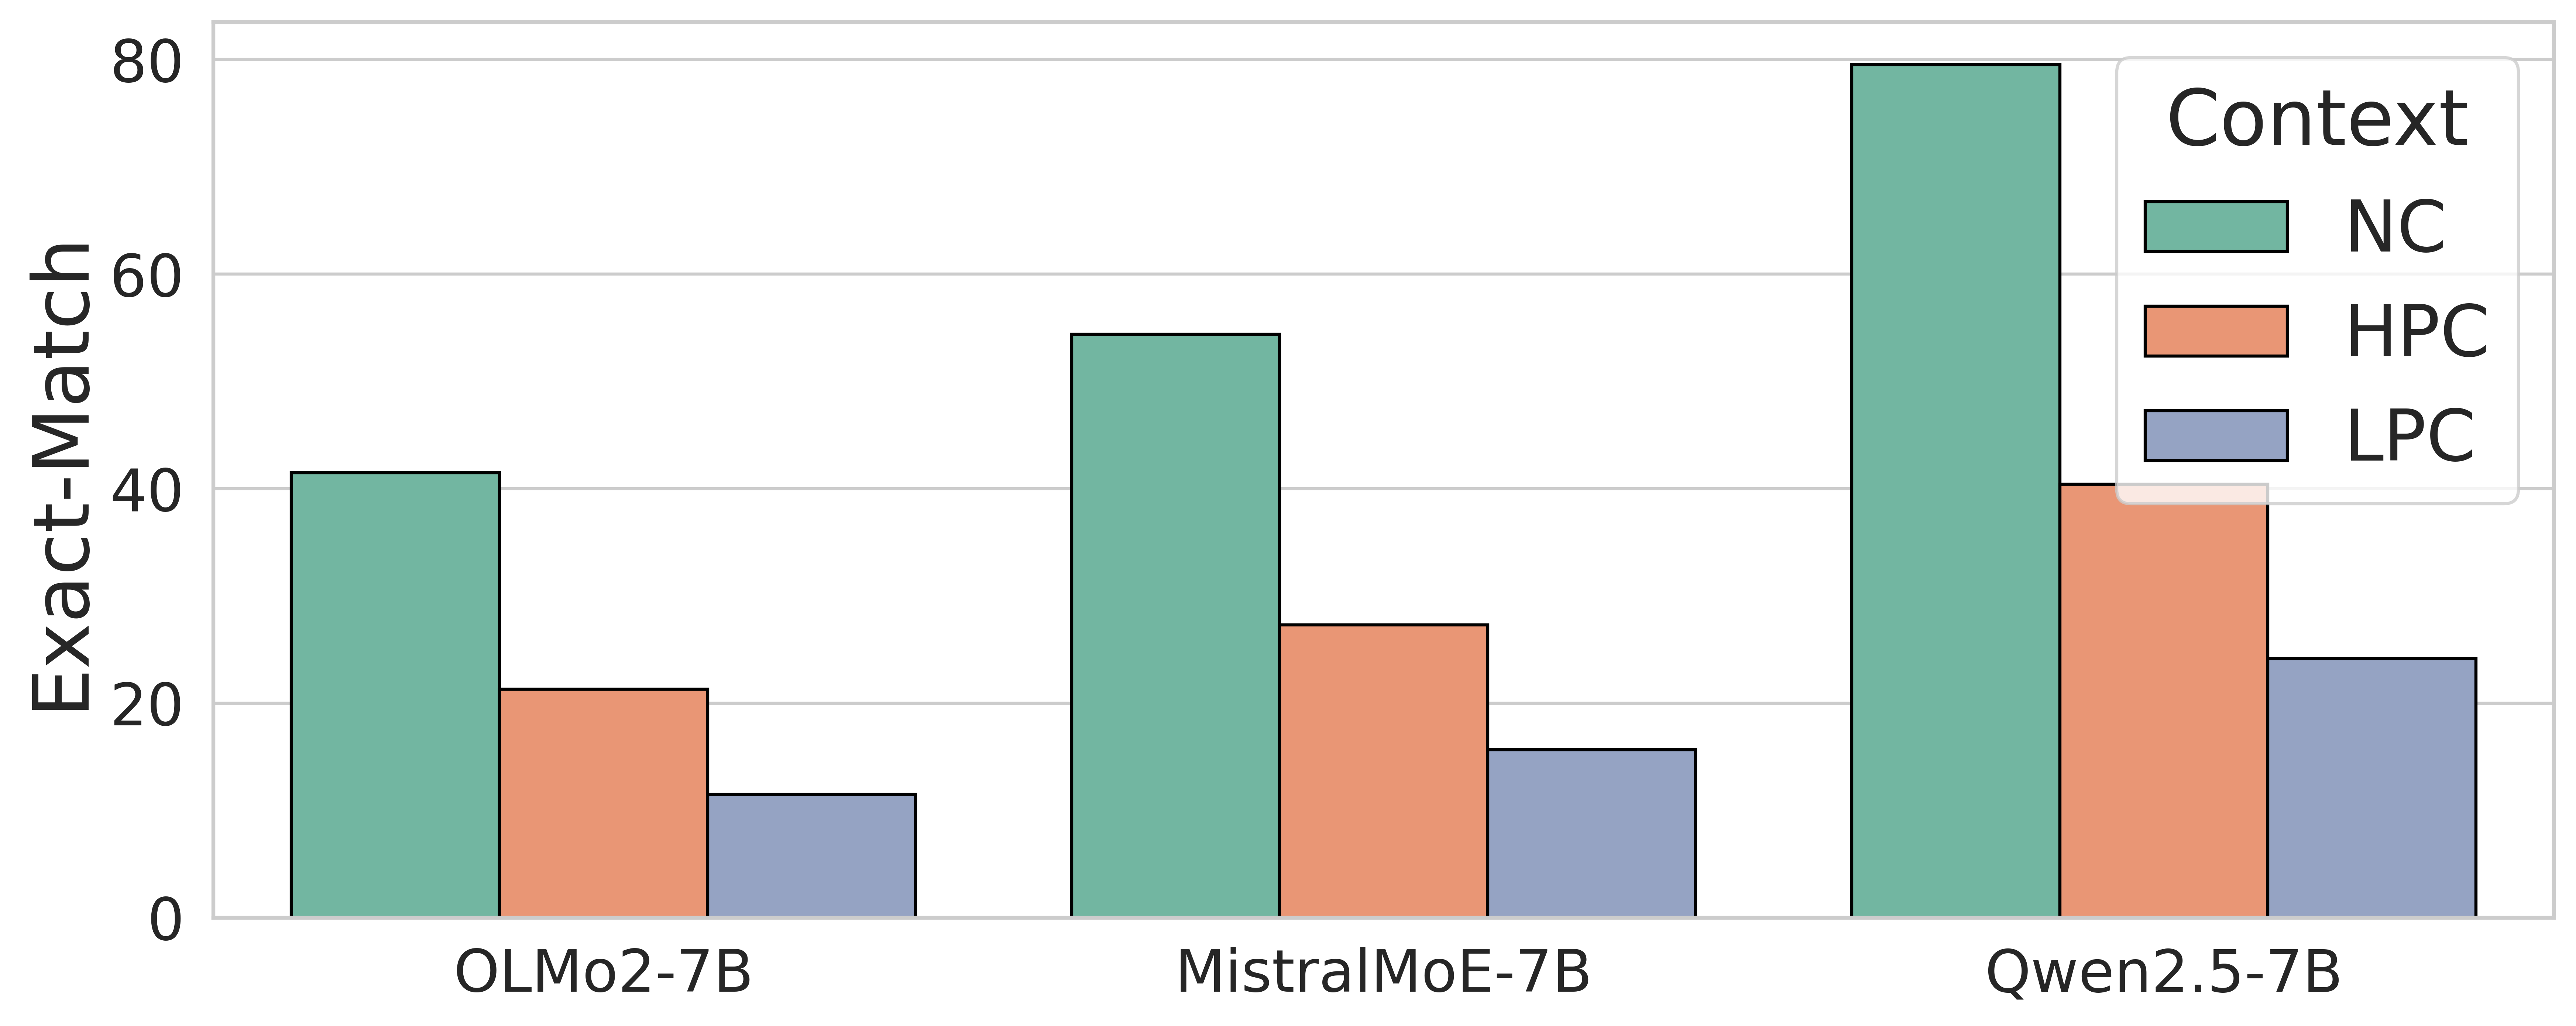

In [10]:
# ------------------------------------------------------------------
# 1)  Combine the three model‑specific DataFrames
# ------------------------------------------------------------------
dfs = []
for name, df in [('OLMo2-7B', perf_olmo), ('MistralMoE-7B', perf_mistral), ('Qwen2.5-7B', perf_qwen)]:
    tmp = df[df['metric'] == 'exact_match'].copy()   # keep only exact‑match rows
    tmp['model'] = name                              # tag the model
    dfs.append(tmp)

data = pd.concat(dfs, ignore_index=True)

# ------------------------------------------------------------------
# 2)  Reshape to long format: one row per (model, task, evidence type)
# ------------------------------------------------------------------
long = data.melt(
    id_vars=['model', 'task'],
    value_vars=['NC', 'HPC', 'LPC'],                 # evidence types to plot
    var_name='evidence',
    value_name='exact_match'
)

# ------------------------------------------------------------------
# 3)  Draw one bar‑plot figure per task
# ------------------------------------------------------------------
sns.set_style('whitegrid')
palette = sns.color_palette('Set2', n_colors=3)      # 3 evidence types → 3 colors

for t in ['KFextract', 'CK', 'PK', 'PCK', 'RAG']:
    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=long[long['task'] == t],
        x='model',
        y='exact_match',
        hue='evidence',
        palette=palette,
        edgecolor='black'
    )
    # plt.title(f'Exact-Match Accuracy by Evidence Type  |  Task: {t}')
    # plt.ylim(0, 1)                                   # remove if values are not proportions
    plt.xlabel('')
    plt.ylabel('Exact-Match')
    plt.legend(title='Context')
    plt.tight_layout()
    plt.savefig(os.path.join(os.environ['base_dir'], "results", "figures", f"{t}.pdf"), bbox_inches='tight')
    plt.show()